# CODE FROM https://lpsmlgeo.github.io/2019-09-22-binary_mask/ by Lucas P. Soares, NOT MY OWN

In [1]:
import os

import rasterio
from rasterio.plot import reshape_as_image
import rasterio.mask
from rasterio.features import rasterize

import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping, Point, Polygon
from shapely.ops import unary_union

import numpy as np
import cv2
import matplotlib.pyplot as plt

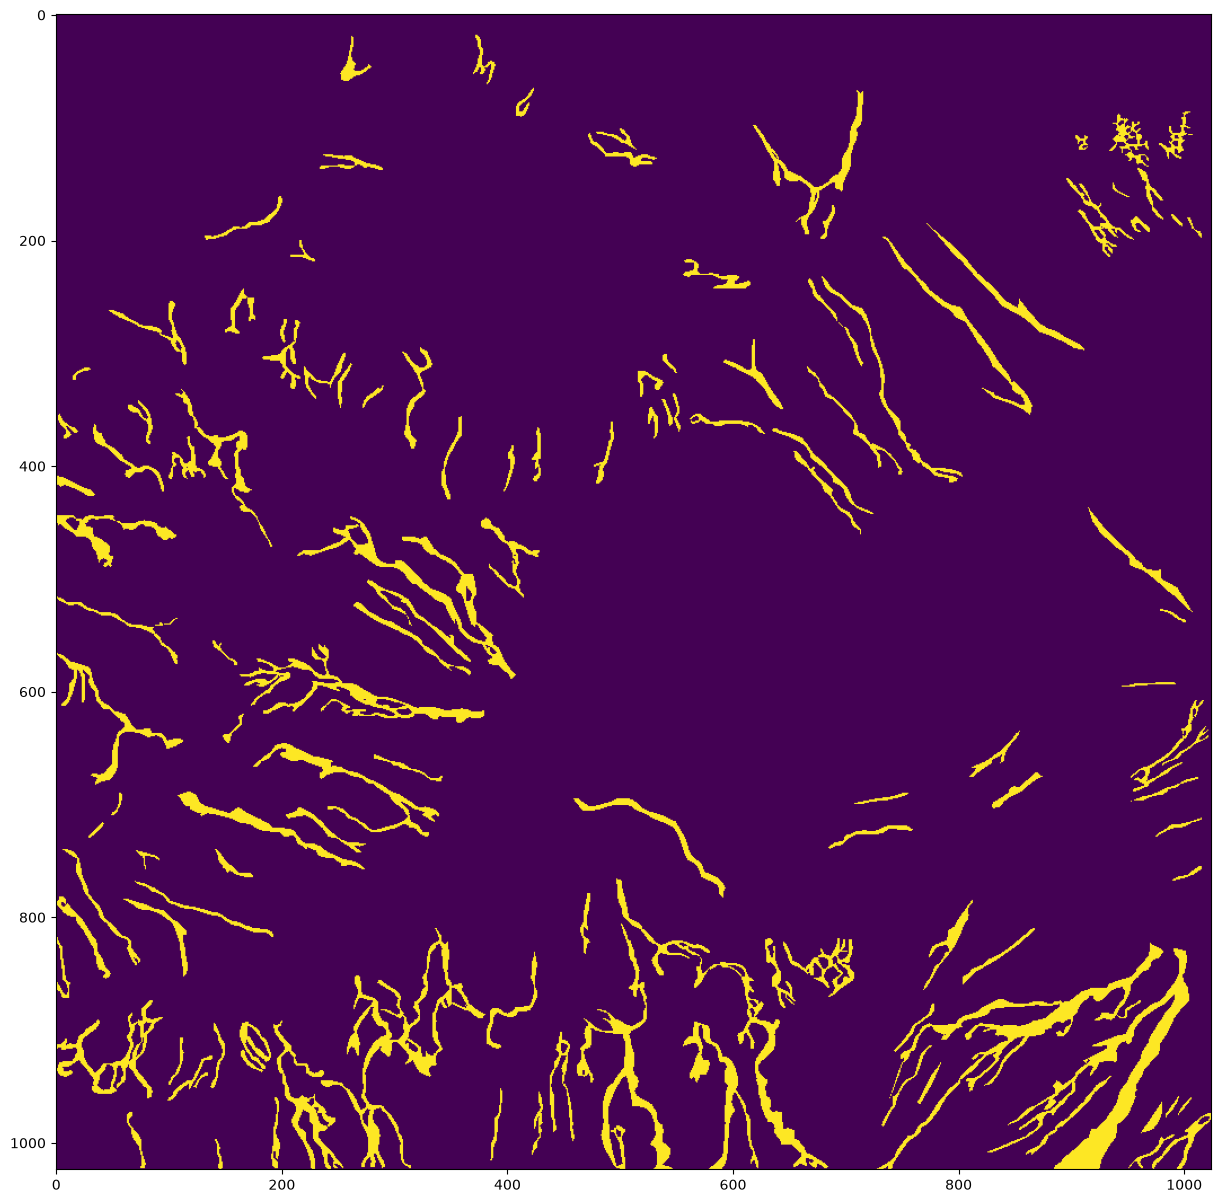

In [2]:
raster_path = fr"D:\Imholte_Research_WT\High_Res_WT_Images_and_Masks\Notebooks\Binary_Mask_Maker\8_2_Image.tif"


with rasterio.open(raster_path, "r") as src:
    raster_img = src.read()
    raster_meta = src.meta

shape_path = fr"D:\Imholte_Research_WT\High_Res_WT_Images_and_Masks\Notebooks\Binary_Mask_Maker\Section_8_2_WT_Polygons.shp"
train_df = gpd.read_file(shape_path)



#Generate polygon
def poly_from_utm(polygon, transform):
    poly_pts = []
    
    poly = unary_union(polygon)
    for i in np.array(poly.exterior.coords):
        
        # Convert polygons to the image CRS
        poly_pts.append(~transform * tuple(i))
        
    # Generate a polygon object
    new_poly = Polygon(poly_pts)
    return new_poly


# Generate Binary maks
poly_shp = []
im_size = (src.meta['height'], src.meta['width'])
for num, row in train_df.iterrows():
    if row['geometry'].geom_type == 'Polygon':
        poly = poly_from_utm(row['geometry'], src.meta['transform'])
        poly_shp.append(poly)
    else:
        for p in row['geometry']:
            poly = poly_from_utm(p, src.meta['transform'])
            poly_shp.append(poly)

mask = rasterize(shapes=poly_shp,
                 out_shape=im_size)


# Plot the mask
plt.figure(figsize=(15,15))
plt.imshow(mask)

In [3]:
mask = mask.astype("uint16")
save_path = fr"D:\Imholte_Research_WT\High_Res_WT_Images_and_Masks\Notebooks\Binary_Mask_Maker\Section_8_2_Gym_Mask.tif"
bin_mask_meta = src.meta.copy()
bin_mask_meta.update({'count': 1})
with rasterio.open(save_path, 'w', **bin_mask_meta) as dst:
    dst.write(mask * 1, 1) #Gabriel changed this to fit the requirements of segmentation_gym; was mask*255 as to stretch rgb